# Week 1 : Data, Machine Learning, and Your First Model

Welcome! This notebook teaches everything for Week 1. Just follow it from the very top, in order : don't skip around.

**How to work through this notebook:**
- Every gray box below is called a "cell." Click on it, then press **Shift + Enter** to run it.
- After you run a cell, **wait a second, look at what it printed or drew, and actually think about it** before moving to the next one. Don't just Shift+Enter through everything quickly.
- Read the text above each cell *before* running the cell : it tells you what you're about to see.
- If something confuses you or gives an error, **stop and write down where you got stuck.** We'll go through it together on the call : that's the whole point.
- Near the bottom, there's a section for you to do yourself, and then a few questions to think about before our call.


## Step 0: Installing the tools this notebook needs

Before we do anything, we need a few extra "toolboxes" (called **packages**) that don't come built into Python by default. Think of it like installing an app before you can use it.

Run the cell below once. It's normal to see some text scroll by : you don't need to read or understand it, just let it finish.


In [1]:
!pip install pandas numpy matplotlib scikit-learn --quiet
print("All set! The toolboxes we need are now installed.")


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
All set! The toolboxes we need are now installed.


## 1. What is "data"?

In Machine Learning, "data" almost always just means **a table** : like a spreadsheet, with rows and columns.

- Each **row** is one example (one measurement, one reading, one thing you observed).
- Each **column** is one piece of information you measured about it : this is called a **feature**.
- If we're trying to predict one of the columns using the others, that column is called the **target** (the thing we're trying to guess).

Here's an example table. Imagine you're in an electronics lab, and for a single resistor, you measure the electric current flowing through it (in **milliamps**, written **mA** : this is just a small unit for measuring current, the same way "centimeters" is a smaller unit than "meters" for measuring length) and the voltage across it (in **volts**, written **V**):

| current_mA | voltage_V |
|---|---|
| 5.93 | 0.576 |
| 7.09 | 0.681 |
| 9.40 | 0.843 |

Here, `current_mA` is a feature. If we're trying to predict voltage from current, `voltage_V` is the target.

You already know from your coursework that voltage, current, and resistance are related (Ohm's Law: V = I × R). So here's the fun question we're about to answer: **if we didn't tell the computer this formula, and just gave it a bunch of example readings, could it figure out the relationship on its own?** That's exactly what we're about to test.


## 2. What is Machine Learning? (in the simplest way possible)

Here's the simplest way to think about it:

> Machine Learning means: instead of a person writing down the exact rule/formula, we give the computer a bunch of examples, and the computer figures out the rule by itself.

Normally in programming, *you* tell the computer exactly what to do, step by step. In Machine Learning, you instead give the computer a pile of examples (like our current/voltage table above) and it searches for the pattern connecting them, without you spelling it out.

**If you want a slightly longer, very beginner-friendly explanation with pictures, watch this short video (about 5 minutes) before continuing:**
📺 https://www.youtube.com/watch?v=Gv9_4yMHFhI

Don't worry about understanding every word in the video : just get the general feeling of "oh, that's what people mean by ML."


## 3. Classification vs. Regression : the two main "types" of problems

Before we get to our specific model, there's one more idea to understand: in Machine Learning, most problems fall into one of two buckets.

- **Classification** = predicting a *category* (a label, a choice from a small fixed list). Examples: "Is this email spam or not spam?", "Is this a picture of a cat or a dog?", "Will it rain tomorrow : yes or no?"
- **Regression** = predicting a *number* (something that can be any value on a scale). Examples: "How many millimeters of rain will fall tomorrow?", "What will the voltage reading be?", "What price will this used car sell for?"

A simple way to remember it: **if the answer is a word/category, it's classification. If the answer is a number, it's regression.**

In our resistor example : we're trying to predict `voltage_V`, which is a number, not a category. So this is a **regression** problem.

**Short video (~5 minutes) that explains this with more examples:**
📺 https://www.youtube.com/watch?v=OeDWBoPxwVE

Watch it if the difference doesn't feel fully clear yet : you'll be asked about this at the end.


## 4. What is pandas?

`pandas` is a Python toolbox (package) whose whole job is: **reading and working with tables of data, inside Python.** Think of it as "Excel, but inside your code" : it's how Python reads a data file and lets you look at rows and columns.

We already installed it in Step 0. Let's use it to open our first real dataset (a CSV file : CSV just means "a table saved as a plain text file, values separated by commas").

Run the cell below. `import pandas as pd` means "load the pandas toolbox and let me refer to it using the short name `pd`" : this is just a convention everyone uses so you don't have to type "pandas" every time.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pandas' read_csv function is how we open a data table into Python
df = pd.read_csv("data/ohms_law_readings.csv")

# .head() shows just the first 5 rows, so we can peek at what the data looks like
df.head()

,current_mA,voltage_V
0,5.93,0.576
1,7.09,0.681
2,7.61,0.562
3,7.93,0.915
4,9.40,0.843


**Understanding check:** we just created something called `df` (short for "dataframe" : pandas' name for a table). Scroll back up, click on the cell above, add a **new empty cell right after it** (hover just below the cell, a small "+ Code" button appears), type just `df` by itself, and run it. What's different from what `.head()` showed you?

*(This is a habit worth building: whenever you're not 100% sure what a variable holds, just type its name in a cell and run it to look at it directly.)*


In [3]:
# .describe() gives you a quick summary: count, average, min, max, etc. for every column
df.describe()

,current_mA,voltage_V
count,40.00000,40.000000
mean,25.53225,2.541525
std,13.30527,1.343087
min,5.93000,0.562000
25%,13.23250,1.323250
50%,24.62500,2.459500
75%,36.05750,3.652750
max,48.65000,4.973000


## 5. What is matplotlib? (don't worry about this one yet!)

You'll notice we already imported something called `matplotlib` up in Step 4 (the line `import matplotlib.pyplot as plt`). **This is just a tool for drawing pictures/graphs from data : that's it.** We are *not* going to explain how it works in detail this week : just run the code below, look at the plot it draws, and don't worry about understanding the plotting code itself yet. We'll cover matplotlib properly in a future week.

Run the cell below, then actually pause for a few seconds and look at the picture. What shape do the dots roughly make?


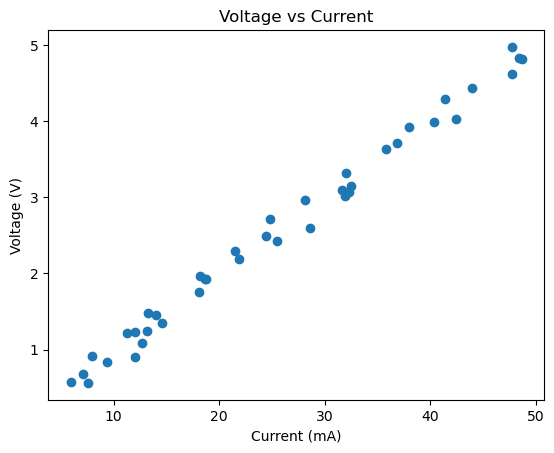

In [4]:
plt.scatter(df["current_mA"], df["voltage_V"])
plt.xlabel("Current (mA)")
plt.ylabel("Voltage (V)")
plt.title("Voltage vs Current")
plt.show()

## 6. What is Linear Regression?

We said earlier that predicting a number (like voltage) is called **regression**. **Linear regression** is the simplest, most basic way to do regression : it means: *find the straight line that best fits through the dots.*

You'll remember from math class that a straight line is written as: `y = m*x + b`
- `m` is the **slope** : how steep the line is (how much y changes each time x goes up by 1).
- `b` is the **intercept** : where the line crosses the y-axis (the value of y when x is 0).

Looking at the scatter plot you just made, the dots roughly form a line. Linear regression is how we get the computer to find the *best possible* `m` and `b` : the line that sits as close as possible to all the dots at once.

In our example: since voltage = current × resistance, the slope `m` that the computer finds is basically the computer's *guess* for the resistance of the resistor : figured out purely from the data, without us ever telling it Ohm's Law.


## 7. Letting sklearn find the line for us (this is the "easy button" way)

`sklearn` (short for "scikit-learn") is a Python toolbox full of ready-made Machine Learning tools : including linear regression, already built for us. We don't have to write the math ourselves to use it.

Here's the idea in plain words before we run any code: we're going to hand `sklearn` our table of current and voltage readings, and say "find me the best straight line through these points." One line of code : `.fit()` : does that entire search for us automatically.


In [5]:
from sklearn.linear_model import LinearRegression

# sklearn wants our feature(s) as a table (2D), and our target as a plain list (1D)
X = df[["current_mA"]]   # the feature we're using to predict from (double brackets keep it a table)
y = df["voltage_V"]      # the target we're trying to predict

model = LinearRegression()
model.fit(X, y)   # this one line does all the work: it searches for the best-fitting line

print("The slope (m) that the computer found:", model.coef_[0])
print("The intercept (b) that the computer found:", model.intercept_)

The slope (m) that the computer found: 0.10044277577717714
The intercept (b) that the computer found: -0.02300506183683071


**Understanding check:** go back up and look at the cell where we created `X` and `y`. Add a new cell right after it, type `X.head()` and run it : what does it look like? Then in another new cell, type `y.head()` : how is it different from `X`? (This is exactly the kind of "just look at the variable" habit from before.)


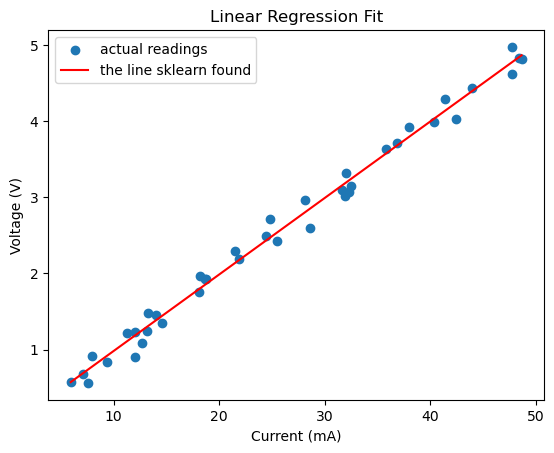

In [6]:
# Let's draw the line the computer found, on top of our actual data points
plt.scatter(df["current_mA"], df["voltage_V"], label="actual readings")
plt.plot(df["current_mA"], model.predict(X), color="red", label="the line sklearn found")
plt.xlabel("Current (mA)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

Notice the slope you got is close to 0.1. That makes sense: our resistor was 100 ohms, and since current was measured in milliamps (thousandths of an amp), voltage = current_mA/1000 × 100 = current_mA × 0.1. **The computer essentially rediscovered the resistor's value just from the readings : nobody told it Ohm's Law.** That's the whole idea of Machine Learning in one small example.


## 8. Doing the exact same thing WITHOUT sklearn (so you see there's no magic)

`.fit()` felt like magic : one line, and it just knew the answer. It's not magic, though : it's following an exact formula called **"least squares."** Let's understand it simply, then do the same calculation ourselves by hand, and check that we get the *exact same* slope and intercept sklearn gave us.

**The simple idea:** for any line you could draw, you can measure how far off it is from each real dot (that gap is called the "error"). Least squares says: square each of those gaps (so negative and positive errors don't cancel out, and big mistakes count extra), add all the squared gaps together, and find the line where that total is as small as possible.

There happens to be a direct formula for the best `m` and `b` : no trial and error needed:

```
m = sum of [(x - average of x) times (y - average of y)]   divided by   sum of [(x - average of x) squared]
b = (average of y)  -  m times (average of x)
```

This is literally what `.fit()` did behind the scenes in Section 7. Let's now type that formula out ourselves in code and see if we get the same numbers.


In [7]:
x_values = df["current_mA"].values   # pull the current column out as plain numbers
y_values = df["voltage_V"].values     # pull the voltage column out as plain numbers

x_avg = np.mean(x_values)   # the average of all current readings
y_avg = np.mean(y_values)   # the average of all voltage readings

m_manual = np.sum((x_values - x_avg) * (y_values - y_avg)) / np.sum((x_values - x_avg) ** 2)
b_manual = y_avg - m_manual * x_avg

print("Slope (m) we calculated by hand:", m_manual)
print("Intercept (b) we calculated by hand:", b_manual)

print()
print("Compare to what sklearn gave us in Section 7:")
print("sklearn's slope:", model.coef_[0])
print("sklearn's intercept:", model.intercept_)

Slope (m) we calculated by hand: 0.10044277577717708
Intercept (b) we calculated by hand: -0.023005061836829377

Compare to what sklearn gave us in Section 7:
sklearn's slope: 0.10044277577717714
sklearn's intercept: -0.02300506183683071


They should match (or be extremely close). That confirms it: `.fit()` isn't magic : it's just running this exact formula for you, faster than you'd type it by hand. Now you've seen both the "quick tool" way and "what's actually happening underneath" way.


---
## 9. Now it's your turn : do the same thing yourself

You're going to repeat every step above, but on a **different, new dataset**: how the resistance of a copper wire changes at different temperatures. This is a real thing in electrical engineering : most conductors' resistance increases in a roughly *straight-line* way as temperature goes up.

**Dataset:** `data/resistance_vs_temperature.csv` : it has two columns: `temperature_C` (temperature in Celsius) and `resistance_ohm` (resistance in ohms). This dataset is already clean (no missing or broken values) : cleaning messy data is a skill for a future week, not this one.

For each step below: write the code yourself, following the exact same pattern we used above for the resistor example. **After each code cell, add a short comment (a line starting with `#`) explaining in your own words what that step is doing for this problem** : just like the explanations you read in Section 1 above, but written by you, in your own words.

If you get stuck on any step: stop, write down exactly where, and move on to the reflection questions below. We'll solve it together on the call.


In [ ]:
# Step 1: Load the dataset with pandas (like Section 4) and look at the first few rows with .head()
# your code here


# your comment here: what did this step do?


In [ ]:
# Step 2: Look at a quick summary with .describe() (like Section 4)
# your code here


# your comment here: what did this step do?


In [ ]:
# Step 3: Make a scatter plot of temperature_C vs resistance_ohm (like Section 5)
# Reminder: this uses matplotlib again -- you still don't need to understand how plotting works,
# just run your code and look at the picture, same as before.
# your code here


# your comment here: what did this step do?


In [ ]:
# Step 4: Fit a LinearRegression model using sklearn (like Section 7)
# feature (X) = temperature_C, target (y) = resistance_ohm
# your code here


# your comment here: what did this step do?


In [ ]:
# Step 5: Plot the fitted line on top of the actual data points (like Section 7)
# your code here


# your comment here: what did this step do?


In [ ]:
# Step 6: Calculate the slope and intercept by hand, without sklearn (like Section 8),
# and print both your manual answer and sklearn's answer to compare them
# your code here


# your comment here: what did this step do, and did the two match?


---
## 10. Reflection questions : think these through for our call

Don't type your answers into this notebook : just think them through (maybe jot notes on paper) so you can explain them out loud when we talk. Everything you need to answer these was covered above, or in the two short videos linked in Sections 2 and 3.

1. **In your own simple words** (not a textbook definition) : what is Machine Learning? Imagine explaining it to a friend who has never heard the term.
2. **What's the difference between classification and regression?** Give one example of each that's different from the examples used in this notebook.
3. **Why is predicting `voltage_V` from `current_mA` a regression problem and not a classification problem?**
4. **Give one real scenario from electrical engineering** (can be from your coursework, or something you make up) where linear regression could be useful, and briefly explain why.

Nice work finishing Week 1! Bring your reflection answers, and any spots where you got stuck in Section 9, to our next call.
